In [15]:
import pandas as pd 
import seaborn as sns 
from datetime import date
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv('Airbnb_Open_Data.csv')

C:\Users\ks\AppData\Local\Temp\ipykernel_40132\2167922700.py:1: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Airbnb_Open_Data.csv')


In [3]:
df = df.drop(columns={'license','reviews per month','last review','house_rules'})

In [4]:
df.dtypes

id                                  int64
NAME                               object
host id                             int64
host_identity_verified             object
host name                          object
neighbourhood group                object
neighbourhood                      object
lat                               float64
long                              float64
country                            object
country code                       object
instant_bookable                   object
cancellation_policy                object
room type                          object
Construction year                 float64
price                              object
service fee                        object
minimum nights                    float64
number of reviews                 float64
review rate number                float64
calculated host listings count    float64
availability 365                  float64
dtype: object

In [5]:
df.isnull().sum()

id                                  0
NAME                              250
host id                             0
host_identity_verified            289
host name                         406
neighbourhood group                29
neighbourhood                      16
lat                                 8
long                                8
country                           532
country code                      131
instant_bookable                  105
cancellation_policy                76
room type                           0
Construction year                 214
price                             247
service fee                       273
minimum nights                    409
number of reviews                 183
review rate number                326
calculated host listings count    319
availability 365                  448
dtype: int64

In [6]:
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)


<>:1: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:1: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
C:\Users\ks\AppData\Local\Temp\ipykernel_40132\1233574569.py:1: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
  df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)


In [7]:
df['year'] = 2025 - df['Construction year']

In [8]:
# حذف الأعمدة التي تحتوي على نسبة عالية من القيم المفقودة (إن وجدت)
df = df.dropna(thresh=len(df)*0.5, axis=1)

# ملء القيم المفقودة أو حذف الصفوف
df['neighbourhood group'] = df['neighbourhood group'].fillna('Unknown')
df['neighbourhood'] = df['neighbourhood'].fillna('Unknown')
df['price'] = df['price'].fillna(df['price'].median())

# حذف الصفوف التي تحتوي على قيم مفقودة في الأعمدة المهمة
df = df.dropna(subset=['price', 'neighbourhood group', 'neighbourhood'])

In [9]:
# تحويل neighbourhood group و neighbourhood إلى متغيرات رقمية
df = pd.get_dummies(df, columns=['neighbourhood group', 'neighbourhood'], drop_first=True)

In [13]:
df.columns

Index(['id', 'NAME', 'host id', 'host_identity_verified', 'host name', 'lat',
       'long', 'country', 'country code', 'instant_bookable',
       ...
       'neighbourhood_Westerleigh', 'neighbourhood_Whitestone',
       'neighbourhood_Williamsbridge', 'neighbourhood_Williamsburg',
       'neighbourhood_Willowbrook', 'neighbourhood_Windsor Terrace',
       'neighbourhood_Woodhaven', 'neighbourhood_Woodlawn',
       'neighbourhood_Woodrow', 'neighbourhood_Woodside'],
      dtype='object', length=252)

In [10]:
# تحويل 'service fee' إذا كان موجوداً
if 'service fee' in df.columns:
    df['service fee'] = df['service fee'].replace('[\$,]', '', regex=True).astype(float)

# إزالة القيم المتطرفة في السعر
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['price'] >= Q1 - 1.5*IQR) & (df['price'] <= Q3 + 1.5*IQR)]

<>:3: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:3: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
C:\Users\ks\AppData\Local\Temp\ipykernel_40132\3102909533.py:3: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
  df['service fee'] = df['service fee'].replace('[\$,]', '', regex=True).astype(float)


In [14]:
features = ['lat', 'long', 'minimum nights', 'number of reviews', 
            'availability 365', 'year']  # أضف الأعمدة الأخرى المهمة

# تأكد من أن جميع الأعمدة موجودة وأنها رقمية
X = df[features].copy()
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')
X = X.fillna(X.mean())

y = df['price']

# 2. تقسيم البيانات
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. تحجيم البيانات
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. بناء وتدريب النموذج
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 5. تقييم النموذج
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse}')
print(f'R² Score: {r2}')

# 6. معاملات النموذج
coefficients = pd.DataFrame({
    'feature': features,
    'coefficient': model.coef_
})
print(coefficients)

RMSE: 330.42756312414554
R² Score: -0.0001569072032219232
             feature  coefficient
0                lat    -2.325975
1               long     1.128582
2     minimum nights    -0.516747
3  number of reviews     1.811032
4   availability 365    -0.202178
5               year     1.969621


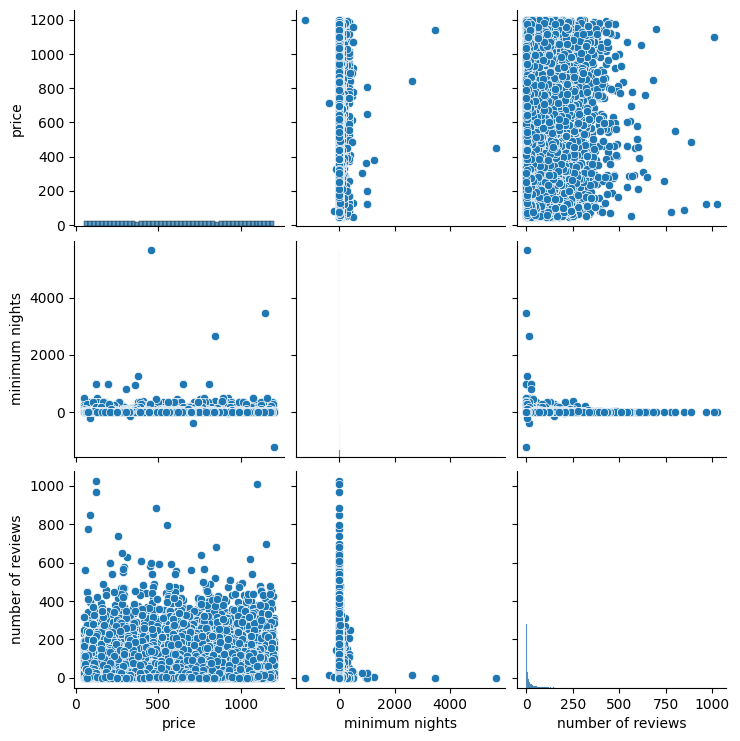

In [16]:
sns.pairplot(df[['price', 'minimum nights', 'number of reviews']])
plt.show()